In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import optuna

c:\Users\USER\anaconda3\envs\ml-maestria\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### 1. Training/Validation data preparation

In [2]:
data = pl.read_csv("data/exp_data.csv").with_row_index()

In [3]:
tie_lines_train = data.sample(fraction=0.8, with_replacement=False, seed=42).sort("index")
tie_lines_validate = data.filter(~data["index"].is_in(tie_lines_train["index"]))
tie_lines_train = tie_lines_train.drop(["index"])
tie_lines_validate = tie_lines_validate.drop(["index"])

In [4]:
X_train = tie_lines_train.select(['Temperature (K)', 'Type Alcohol', 'FAME/FAEE_F', 'GLYCEROL_F', 'ALCOHOL_F', 'OIL_F', 'DAG_F', 'MAG_F', 
                                  'ACID_F', 'WATER_F','MW_FAME/FAEE', 'MW_Oil', 'MW_DAG', 'MW_MAG', 'MW_FA']).to_numpy()
y_train = tie_lines_train.select(['FAME/FAEE_L', 'GLYCEROL_L', 'ALCOHOL_L', 'OIL_L', 'DAG_L', 'MAG_L', 'ACID_L', 'WATER_L', 'FAME/FAEE_H', 'GLYCEROL_H', 
                                  'ALCOHOL_H', 'OIL_H', 'DAG_H', 'MAG_H', 'ACID_H', 'WATER_H']).to_numpy()

In [5]:
X_val= tie_lines_validate.select(['Temperature (K)', 'Type Alcohol', 'FAME/FAEE_F', 'GLYCEROL_F', 'ALCOHOL_F', 'OIL_F', 'DAG_F', 'MAG_F', 
                                  'ACID_F', 'WATER_F','MW_FAME/FAEE', 'MW_Oil', 'MW_DAG', 'MW_MAG', 'MW_FA']).to_numpy()
y_val = tie_lines_validate.select(['FAME/FAEE_L', 'GLYCEROL_L', 'ALCOHOL_L', 'OIL_L', 'DAG_L', 'MAG_L', 'ACID_L', 'WATER_L', 'FAME/FAEE_H', 'GLYCEROL_H', 
                                  'ALCOHOL_H', 'OIL_H', 'DAG_H', 'MAG_H', 'ACID_H', 'WATER_H']).to_numpy()

In [6]:
X_total = data.select(['Temperature (K)', 'Type Alcohol', 'FAME/FAEE_F', 'GLYCEROL_F', 'ALCOHOL_F', 'OIL_F', 'DAG_F', 'MAG_F', 
                                  'ACID_F', 'WATER_F','MW_FAME/FAEE', 'MW_Oil', 'MW_DAG', 'MW_MAG', 'MW_FA']).to_numpy()
y_total = data.select(['FAME/FAEE_L', 'GLYCEROL_L', 'ALCOHOL_L', 'OIL_L', 'DAG_L', 'MAG_L', 'ACID_L', 'WATER_L', 'FAME/FAEE_H', 'GLYCEROL_H', 
                                  'ALCOHOL_H', 'OIL_H', 'DAG_H', 'MAG_H', 'ACID_H', 'WATER_H']).to_numpy()

#### 2. Evaluation functions

In [7]:
def metrics(y_train, y_val, y_total, y_pred_train, y_pred_val, y_pred_total):
    
    r2_train = r2_score(y_train, y_pred_train)
    r2_val = r2_score(y_val, y_pred_val)
    r2_total = r2_score(y_total, y_pred_total)

    RMSE_train = root_mean_squared_error(y_train, y_pred_train)
    RMSE_val = root_mean_squared_error(y_val, y_pred_val)
    RMSE_total = root_mean_squared_error(y_total, y_pred_total)
    
    print(f"Training: R2: {round(r2_train, 4)} \n RMSE: {round(RMSE_train, 4)}")
    print(f"Validate: R2: {round(r2_val, 4)} \n RMSE: {round(RMSE_val, 4)}")
    print(f"Total: R2: {round(r2_total, 4)} \n RMSE: {round(RMSE_total, 4)}")
    

In [8]:
def graph_corr(y_true, y_pred, title, save):
    sns.set_theme(rc={'figure.figsize':(15,8)})
    sns.set_style("whitegrid")

    sns.lineplot(x = [0,1], y=[0,1], color = "black")
    sns.scatterplot(x = y_true[:, 0], y = y_pred[:, 0], facecolor = "none", edgecolor = "red", label = "FAME/FAEE")
    sns.scatterplot(x = y_true[:, 8], y = y_pred[:, 8], facecolor = "none", edgecolor = "red")

    sns.scatterplot(x = y_true[:, 1], y = y_pred[:, 1], facecolor = "none", edgecolor = "blue", label = "Glycerol")
    sns.scatterplot(x = y_true[:, 9], y = y_pred[:, 9], facecolor = "none", edgecolor = "blue")

    sns.scatterplot(x = y_true[:, 2], y = y_pred[:, 2], facecolor = "none", edgecolor = "green", label = "Alcohol")
    sns.scatterplot(x = y_true[:, 10], y = y_pred[:, 10], facecolor = "none", edgecolor = "green")

    sns.scatterplot(x = y_true[:, 3], y = y_pred[:, 3], facecolor = "none", edgecolor = "orange", label = "Oil")
    sns.scatterplot(x = y_true[:, 11], y = y_pred[:, 11], facecolor = "none", edgecolor = "orange")

    sns.scatterplot(x = y_true[:, 4], y = y_pred[:, 4], facecolor = "none", edgecolor = "goldenrod", label = "DAG")
    sns.scatterplot(x = y_true[:, 12], y = y_pred[:, 12], facecolor = "none", edgecolor = "goldenrod")

    sns.scatterplot(x = y_true[:, 5], y = y_pred[:, 5], facecolor = "none", edgecolor = "darkviolet", label = "MAG")
    sns.scatterplot(x = y_true[:, 13], y = y_pred[:, 13], facecolor = "none", edgecolor = "darkviolet")

    sns.scatterplot(x = y_true[:, 6], y = y_pred[:, 6], facecolor = "none", edgecolor = "darkcyan", label = "Acid")
    sns.scatterplot(x = y_true[:, 14], y = y_pred[:, 14], facecolor = "none", edgecolor = "darkcyan")

    sns.scatterplot(x = y_true[:, 7], y = y_pred[:, 7], facecolor = "none", edgecolor = "magenta", label = "Water")
    sns.scatterplot(x = y_true[:, 15], y = y_pred[:, 15], facecolor = "none", edgecolor = "magenta")

    plt.xlabel("Experimental composition (%w)", fontsize=16)
    plt.ylabel("Calculated composition (%w)", fontsize=16)
    plt.legend(loc = "upper left")
    sns.set_context("talk", font_scale=2)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.title(title)
    if save == True:
        plt.savefig('UNIFACD_CORR_new.png', dpi=1000, bbox_inches='tight')
        
    plt.show()
    

#### 3. Models

##### 3.1 Random Forest

In [27]:
rf = RandomForestRegressor(random_state=42, n_estimators=50, max_depth=7)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=7, n_estimators=50, random_state=42)

In [28]:
y_pred_train = rf.predict(X_train)
y_pred_val = rf.predict(X_val)
y_pred_total = rf.predict(X_total)

In [29]:
metrics(y_train, y_val, y_total, y_pred_train, y_pred_val, y_pred_total)

Training: R2: 0.9427 
 RMSE: 0.0116
Validate: R2: 0.891 
 RMSE: 0.017
Total: R2: 0.934 
 RMSE: 0.0129


In [30]:
# Save the model
#with open("random_forest_model.pkl", "wb") as f:
    #pickle.dump(rf, f)

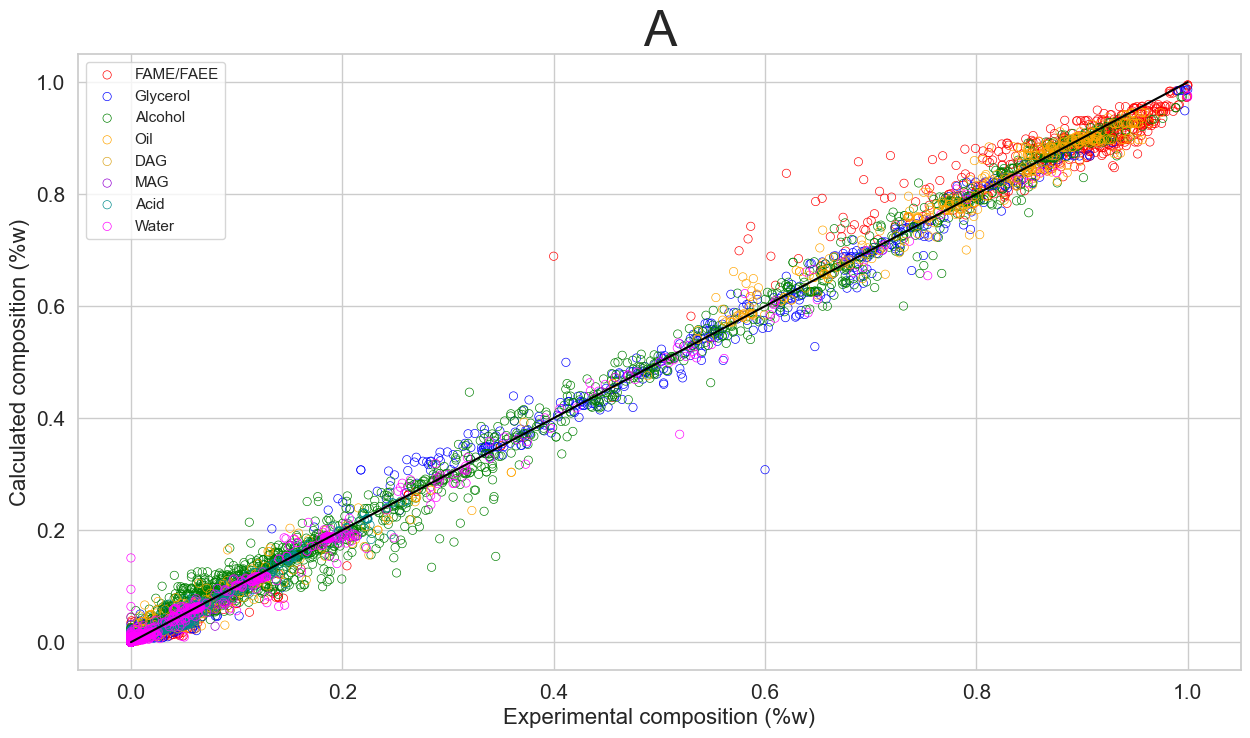

In [31]:
graph_corr(y_train, y_pred_train, "A", False)

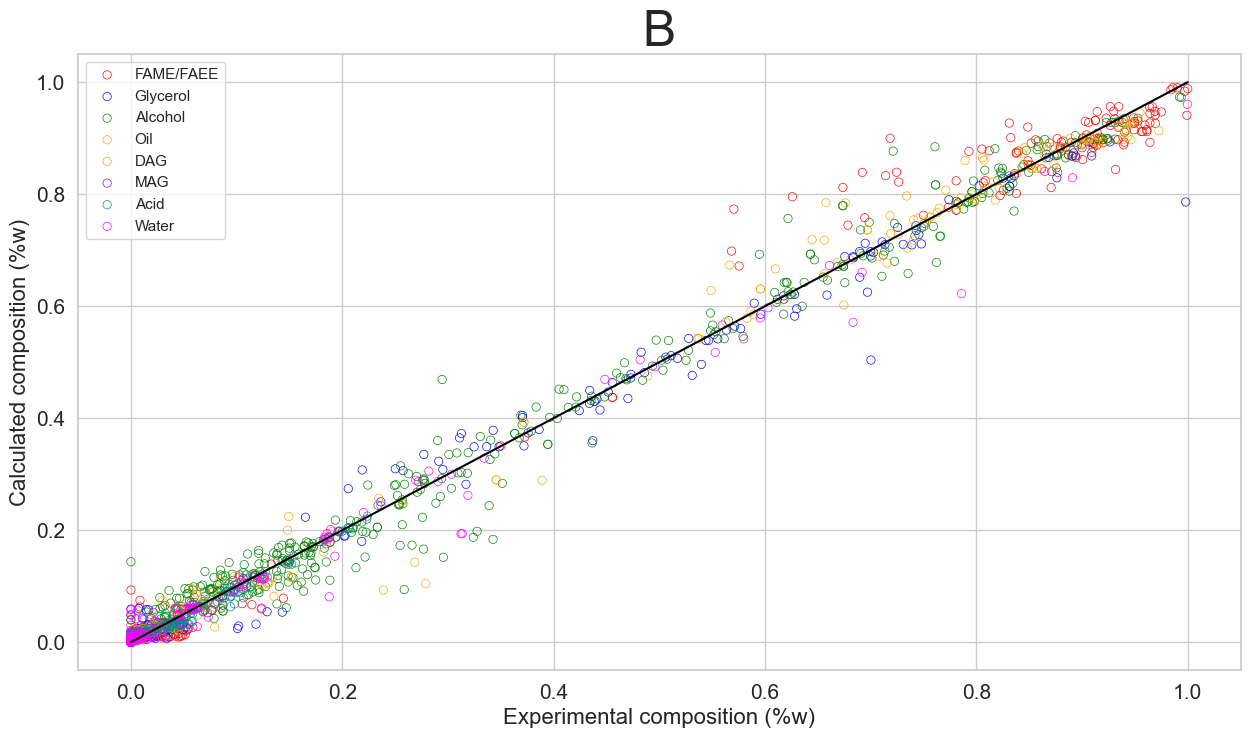

In [32]:
graph_corr(y_val, y_pred_val, "B", False)

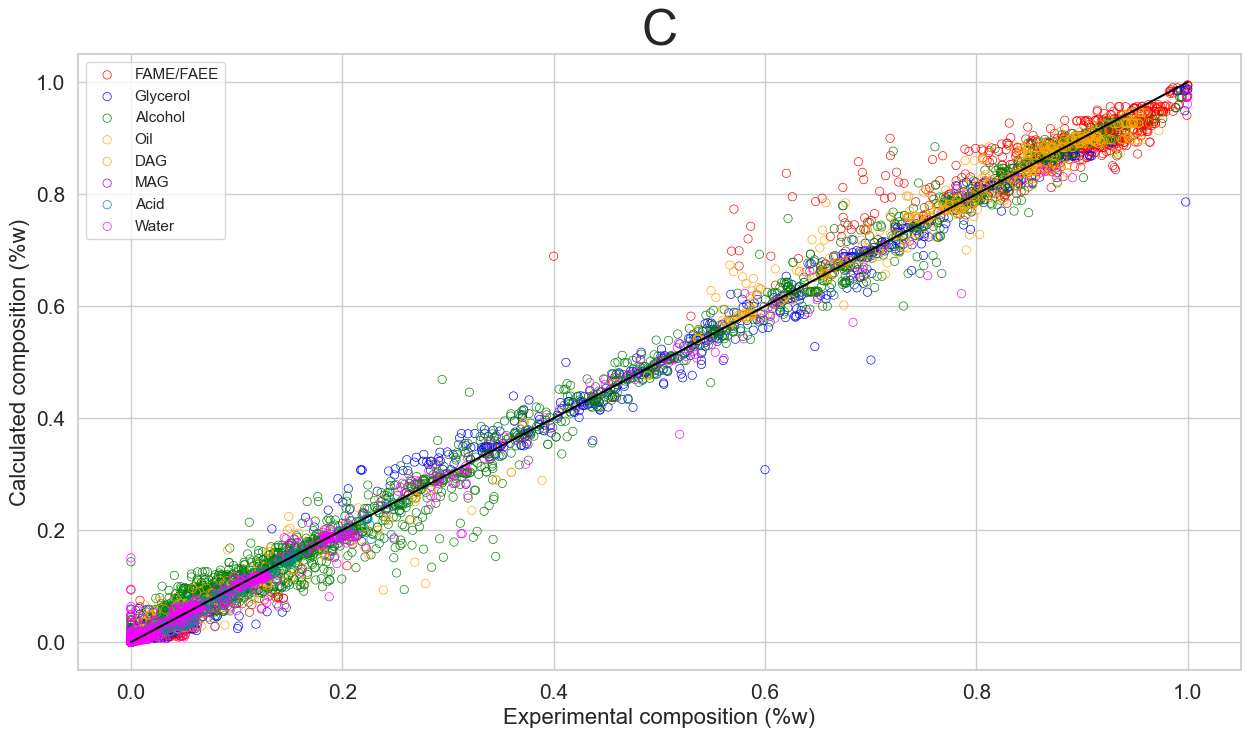

In [33]:
graph_corr(y_total, y_pred_total, "C", False)

##### 3.2 XGBoost Regressor

In [208]:
xgb_regressor = XGBRegressor(n_estimators=85, max_depth=6, learning_rate=0.05)
xgb_regressor.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=85,
             n_jobs=None, num_parallel_tree=None, ...)

In [209]:
y_pred_train = xgb_regressor.predict(X_train)
y_pred_val = xgb_regressor.predict(X_val)
y_pred_total = xgb_regressor.predict(X_total)

In [210]:
metrics(y_train, y_val, y_total, y_pred_train, y_pred_val, y_pred_total)

Training: R2: 0.9635 
 RMSE: 0.0068
Validate: R2: 0.9134 
 RMSE: 0.0155
Total: R2: 0.9548 
 RMSE: 0.0093


In [211]:
# Save the model
#with open("xgb_regressor_model.pkl", "wb") as f:
    #pickle.dump(xgb_regressor, f)

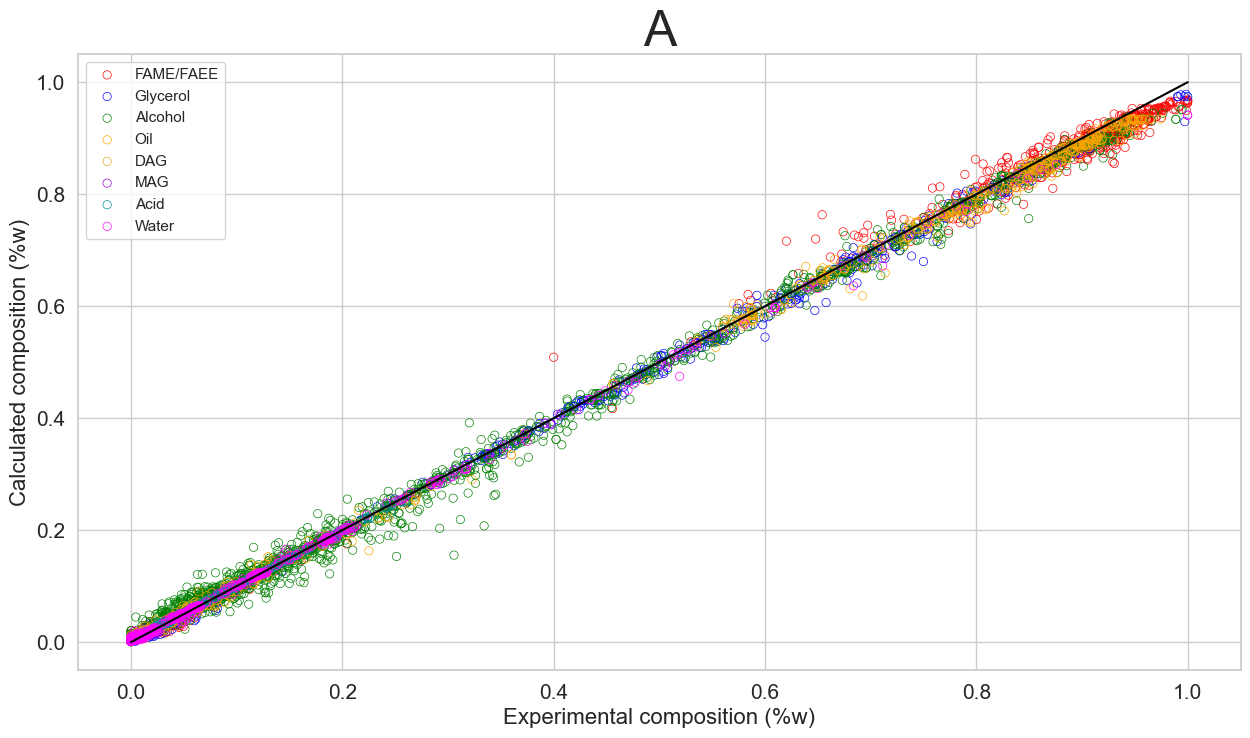

In [212]:
graph_corr(y_train, y_pred_train, "A", False)

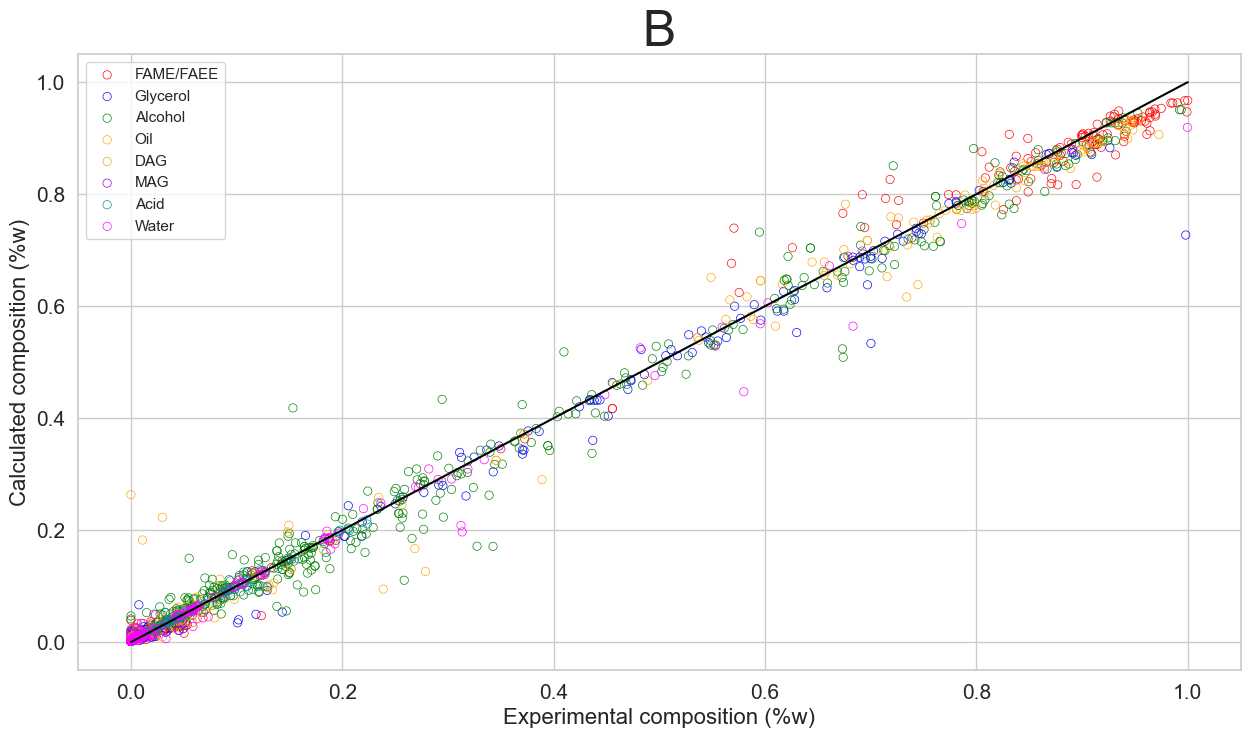

In [213]:
graph_corr(y_val, y_pred_val, "B", False)

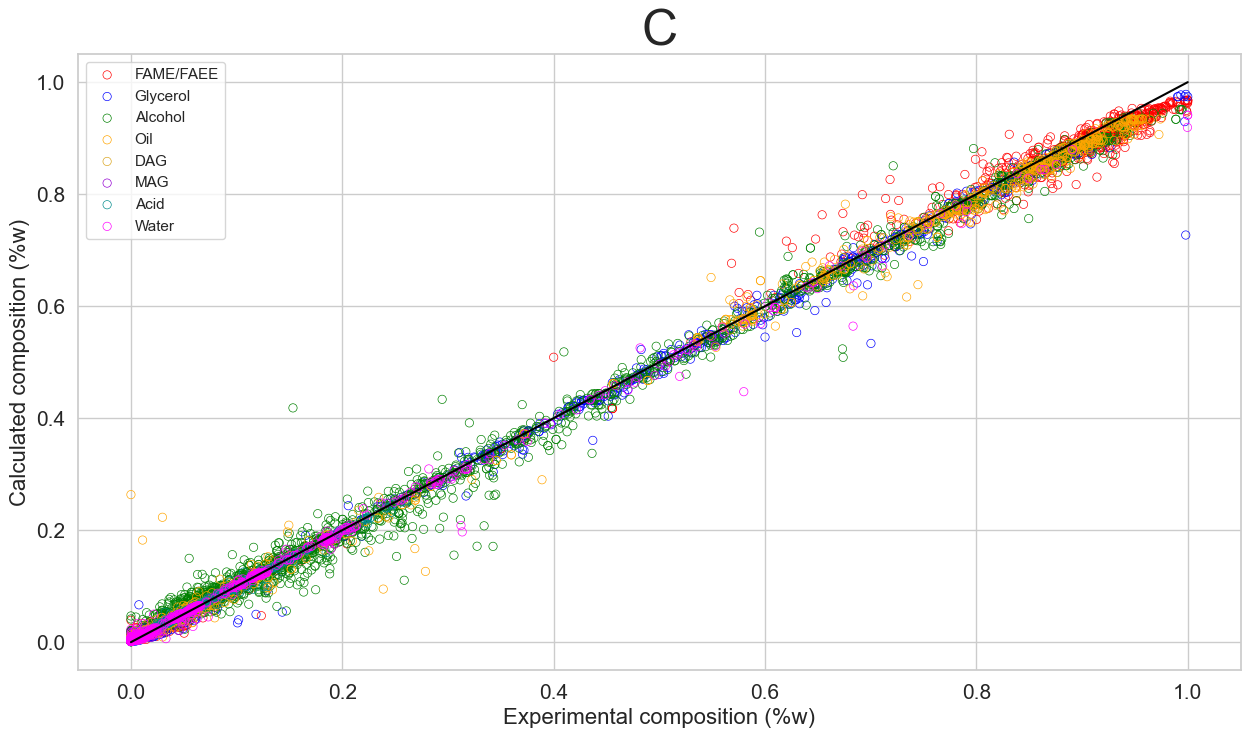

In [214]:
graph_corr(y_total, y_pred_total, "C", False)

##### 3.3 MLP

In [10]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_total_scaled = scaler.transform(X_total)

In [11]:
def objective(trial):
    hidden_layer_sizes = tuple([trial.suggest_int("n_units_l" + str(i), 10, 100) for i in range(trial.suggest_int("n_layers", 1, 3))])
    activation = trial.suggest_categorical("activation", ["relu", "tanh", "logistic"])
    alpha = trial.suggest_float("alpha", 1e-5, 1e-1)
    learning_rate_init = trial.suggest_float("learning_rate_init", 1e-4, 1e-1)
    
    model = MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        alpha=alpha,
        learning_rate_init=learning_rate_init,
        max_iter=500,
        random_state=42
    )
    
    model.fit(X_train_scaled, y_train) 
    y_pred_val = model.predict(X_val_scaled)
    r2 = r2_score(y_val, y_pred_val) 
    RMSE = root_mean_squared_error(y_val, y_pred_val)
    return r2, RMSE


In [14]:
# Run Optuna optimization
study = optuna.create_study(directions=["maximize", "minimize"])  # We maximize negative MSE (i.e., minimize MSE)
study.optimize(objective, n_trials=1000)

[I 2025-04-02 17:36:06,686] A new study created in memory with name: no-name-06057c54-d7e5-43c2-9dff-70dc64fd8e64
[I 2025-04-02 17:36:06,847] Trial 0 finished with values: [0.19933204813676875, 0.03597705473673478] and parameters: {'n_layers': 1, 'n_units_l0': 67, 'activation': 'tanh', 'alpha': 0.07523790265818281, 'learning_rate_init': 0.018944705487710083}.
[I 2025-04-02 17:36:07,592] Trial 1 finished with values: [-1.5769519538664896, 0.10134123070916522] and parameters: {'n_layers': 3, 'n_units_l0': 50, 'n_units_l1': 30, 'n_units_l2': 57, 'activation': 'logistic', 'alpha': 0.09283876609421568, 'learning_rate_init': 0.08602769666265248}.
[I 2025-04-02 17:36:09,005] Trial 2 finished with values: [-0.0172569344035694, 0.03622150104222445] and parameters: {'n_layers': 3, 'n_units_l0': 89, 'n_units_l1': 95, 'n_units_l2': 39, 'activation': 'relu', 'alpha': 0.09654558019816323, 'learning_rate_init': 0.028877102657296365}.
[I 2025-04-02 17:36:09,248] Trial 3 finished with values: [-0.13212

In [15]:
print("Best hyperparameters:", study.best_trials)

Best hyperparameters: [FrozenTrial(number=277, state=1, values=[0.8087382183086569, 0.020034952420833363], datetime_start=datetime.datetime(2025, 4, 2, 17, 38, 6, 179442), datetime_complete=datetime.datetime(2025, 4, 2, 17, 38, 6, 675512), params={'n_layers': 3, 'n_units_l0': 82, 'n_units_l1': 64, 'n_units_l2': 94, 'activation': 'relu', 'alpha': 0.024957011343107172, 'learning_rate_init': 0.015462970906804903}, user_attrs={}, system_attrs={'nsga2:generation': 5}, intermediate_values={}, distributions={'n_layers': IntDistribution(high=3, log=False, low=1, step=1), 'n_units_l0': IntDistribution(high=100, log=False, low=10, step=1), 'n_units_l1': IntDistribution(high=100, log=False, low=10, step=1), 'n_units_l2': IntDistribution(high=100, log=False, low=10, step=1), 'activation': CategoricalDistribution(choices=('relu', 'tanh', 'logistic')), 'alpha': FloatDistribution(high=0.1, log=False, low=1e-05, step=None), 'learning_rate_init': FloatDistribution(high=0.1, log=False, low=0.0001, step=

In [24]:
study.best_trials[0].params

{'n_layers': 3,
 'n_units_l0': 82,
 'n_units_l1': 64,
 'n_units_l2': 94,
 'activation': 'relu',
 'alpha': 0.024957011343107172,
 'learning_rate_init': 0.015462970906804903}

In [25]:
mlp_regressor = MLPRegressor(random_state=42, max_iter=2000, hidden_layer_sizes=(study.best_trials[0].params["n_units_l0"], study.best_trials[0].params["n_units_l1"], study.best_trials[0].params["n_units_l2"]), 
                             activation=study.best_trials[0].params["activation"], alpha=study.best_trials[0].params["alpha"], 
                             learning_rate_init=study.best_trials[0].params["learning_rate_init"])
mlp_regressor.fit(X_train_scaled, y_train)

MLPRegressor(alpha=0.024957011343107172, hidden_layer_sizes=(82, 64, 94),
             learning_rate_init=0.015462970906804903, max_iter=2000,
             random_state=42)

In [26]:
y_pred_train = mlp_regressor.predict(X_train_scaled)
y_pred_val = mlp_regressor.predict(X_val_scaled)
y_pred_total = mlp_regressor.predict(X_total_scaled)

In [27]:
metrics(y_train, y_val, y_total, y_pred_train, y_pred_val, y_pred_total)

Training: R2: 0.7784 
 RMSE: 0.0169
Validate: R2: 0.8087 
 RMSE: 0.02
Total: R2: 0.7876 
 RMSE: 0.0176


In [31]:
# Save the model
with open("mlp_model.pkl", "wb") as f:
    pickle.dump(mlp_regressor, f)

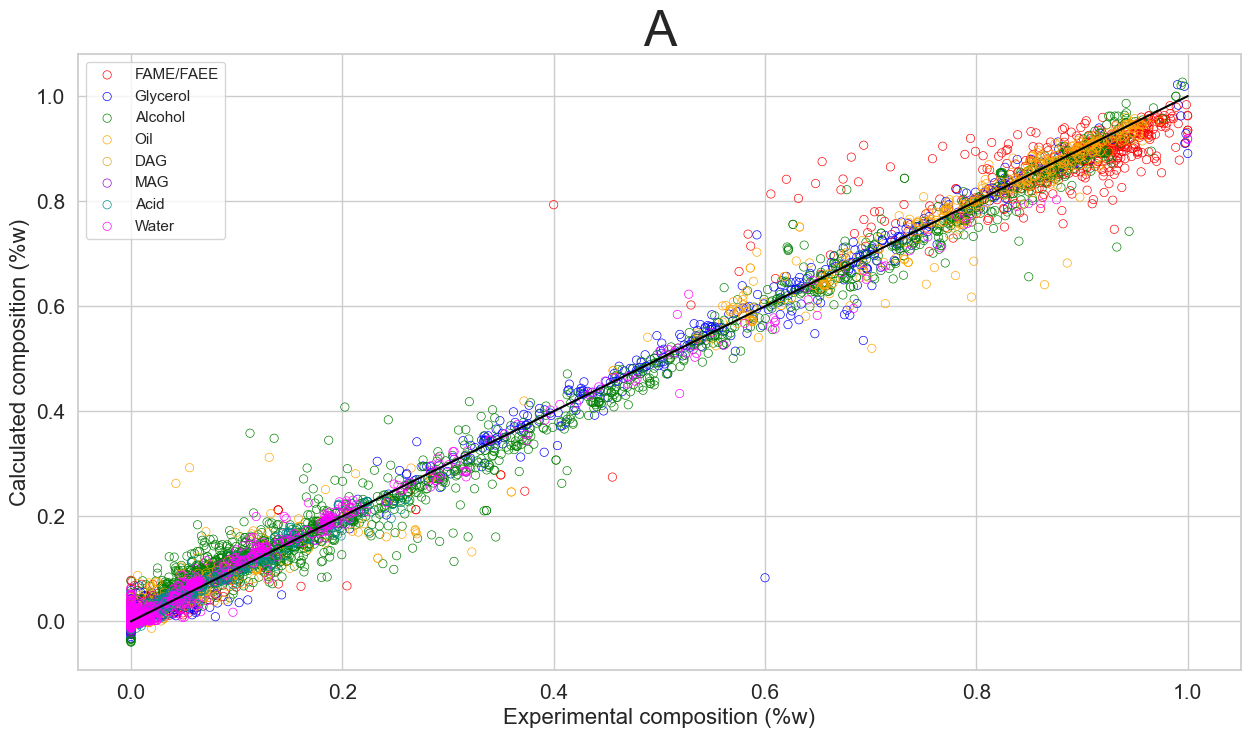

In [28]:
graph_corr(y_train, y_pred_train, "A", False)

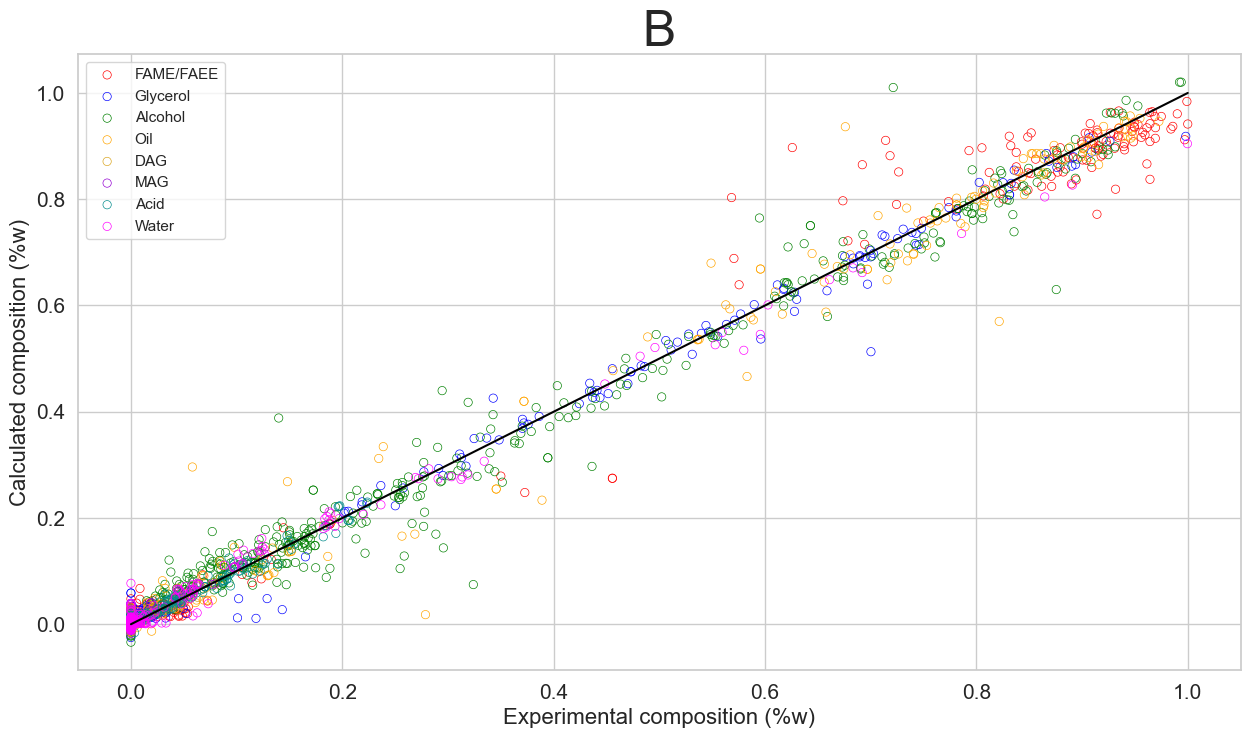

In [29]:
graph_corr(y_val, y_pred_val, "B", False)

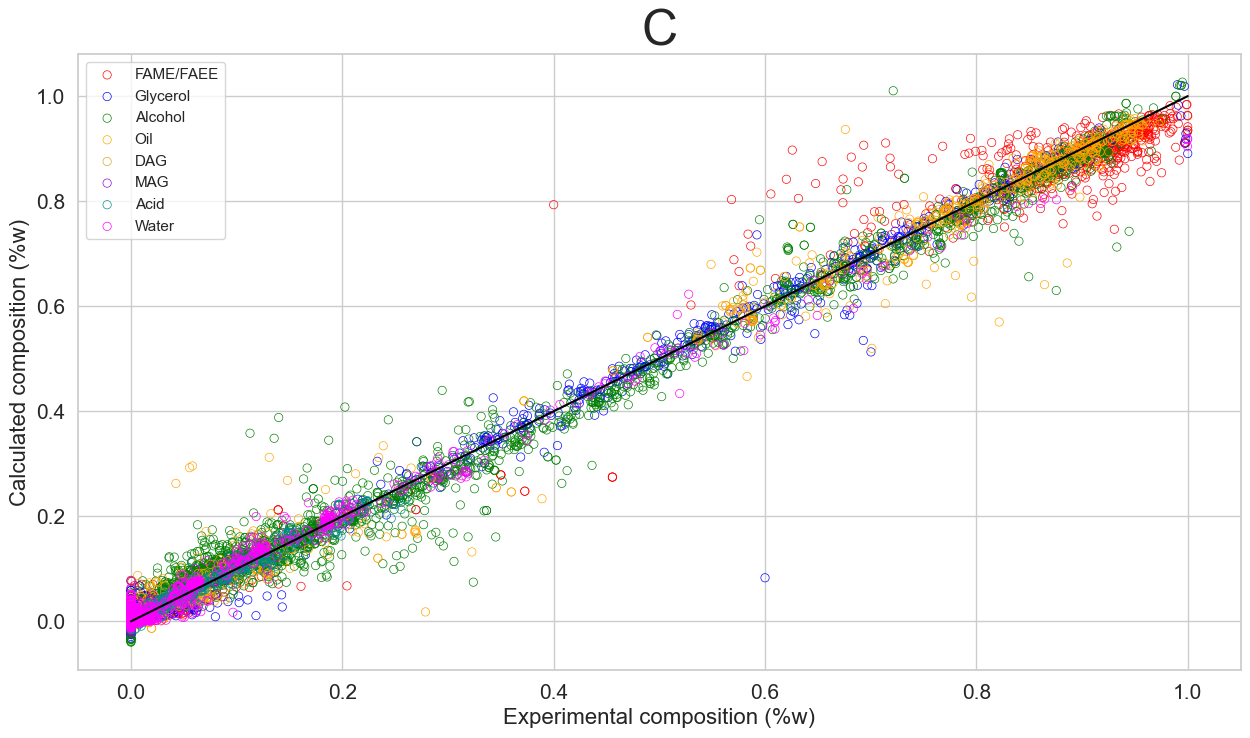

In [30]:
graph_corr(y_total, y_pred_total, "C", False)